In [1]:
!pip install pyspark
import pyspark
from pyspark.sql import SparkSession
spark = SparkSession.builder.config("spark.driver.memory", "15g").getOrCreate()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 MB 3.5 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 13.2 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.3.1-py2.py3-none-any.whl size=281845513 sha256=2bec8a1a4706d5d02ef73cbea260008feb4bb2737d166023cf3bf67da33b121c
  Stored in directory: /root/.cache/pip/wheels/42/59/f5/79a5bf931714dcd201b26025347785f087370a10a3329a899c
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.7
    Uninstalling py4j-0.10.9.7:
      Successfully uninstalled py4j-0.10.9.7


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


22/11/30 14:39:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [16]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# Helper function
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [4]:
import pandas as pd
df1=spark.read.format("csv").option("header","true").load("../input/project-data/train_transaction.csv")
df1_train = pd.read_csv('../input/project-data/train_transaction.csv')

train_transaction = reduce_mem_usage(df1_train)
train_transaction.head()
df=spark.read.format("csv").option("header","true").load("../input/project-data/train_identity.csv")
df_iden = pd.read_csv("../input/project-data/train_identity.csv")

train_identity = reduce_mem_usage(df_iden)
#df1_train.shape
train_df = pd.merge(train_transaction, train_identity, how='left')
print(train_df.shape)
len_train_df = len(train_df)
del train_transaction, train_identity, df1_train, df_iden
train_df.head()
test_transaction = pd.read_csv("../input/project-data/test_transaction.csv")
print(test_transaction.shape)
test_transaction = reduce_mem_usage(test_transaction)

test_identity = pd.read_csv("../input/project-data/test_identity.csv")
print(test_identity.shape)
test_identity = reduce_mem_usage(test_identity)

test_df = pd.merge(test_transaction, test_identity, how='left')
test_df.columns = train_df.drop('isFraud', axis=1).columns
print(test_df.shape)
del test_transaction, test_identity
test_df.head()

Memory usage of dataframe is 1775.15 MB
Memory usage after optimization is: 487.16 MB
Decreased by 72.6%
Memory usage of dataframe is 45.12 MB
Memory usage after optimization is: 10.00 MB
Decreased by 77.8%
(590540, 434)
(506691, 393)
Memory usage of dataframe is 1519.24 MB
Memory usage after optimization is: 425.24 MB
Decreased by 72.0%
(141907, 41)
Memory usage of dataframe is 44.39 MB
Memory usage after optimization is: 9.84 MB
Decreased by 77.8%
(506691, 433)


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3663549,18403224,31.953125,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000000,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000000,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,285.000000,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.937500,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print("Number of column in train_transaction before column deletion: ")
len(df1.columns)

Number of column in train_transaction before column deletion: 


394

In [9]:
df1.show()

22/11/28 03:37:48 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------+-------+-------------+--------------+---------+-----+-----+-----+----------+-----+------+-----+-----+-----+-----+-------------+-------------+---+---+---+---+---+---+---+---+---+---+---+---+----+---+-----+-----+----+-----+----+----+----+----+----+-----+-----+----+----+----+-----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+---+----+----+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+------+-----+----+-----+-----+---

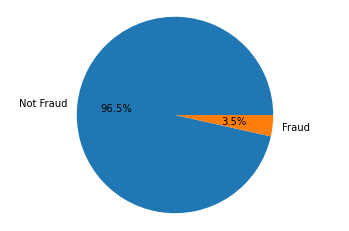

In [10]:
plt.pie(train_df.isFraud.value_counts(), labels=['Not Fraud', 'Fraud'], autopct='%0.1f%%')
plt.axis('equal')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0, 0.5, 'Missing rate')

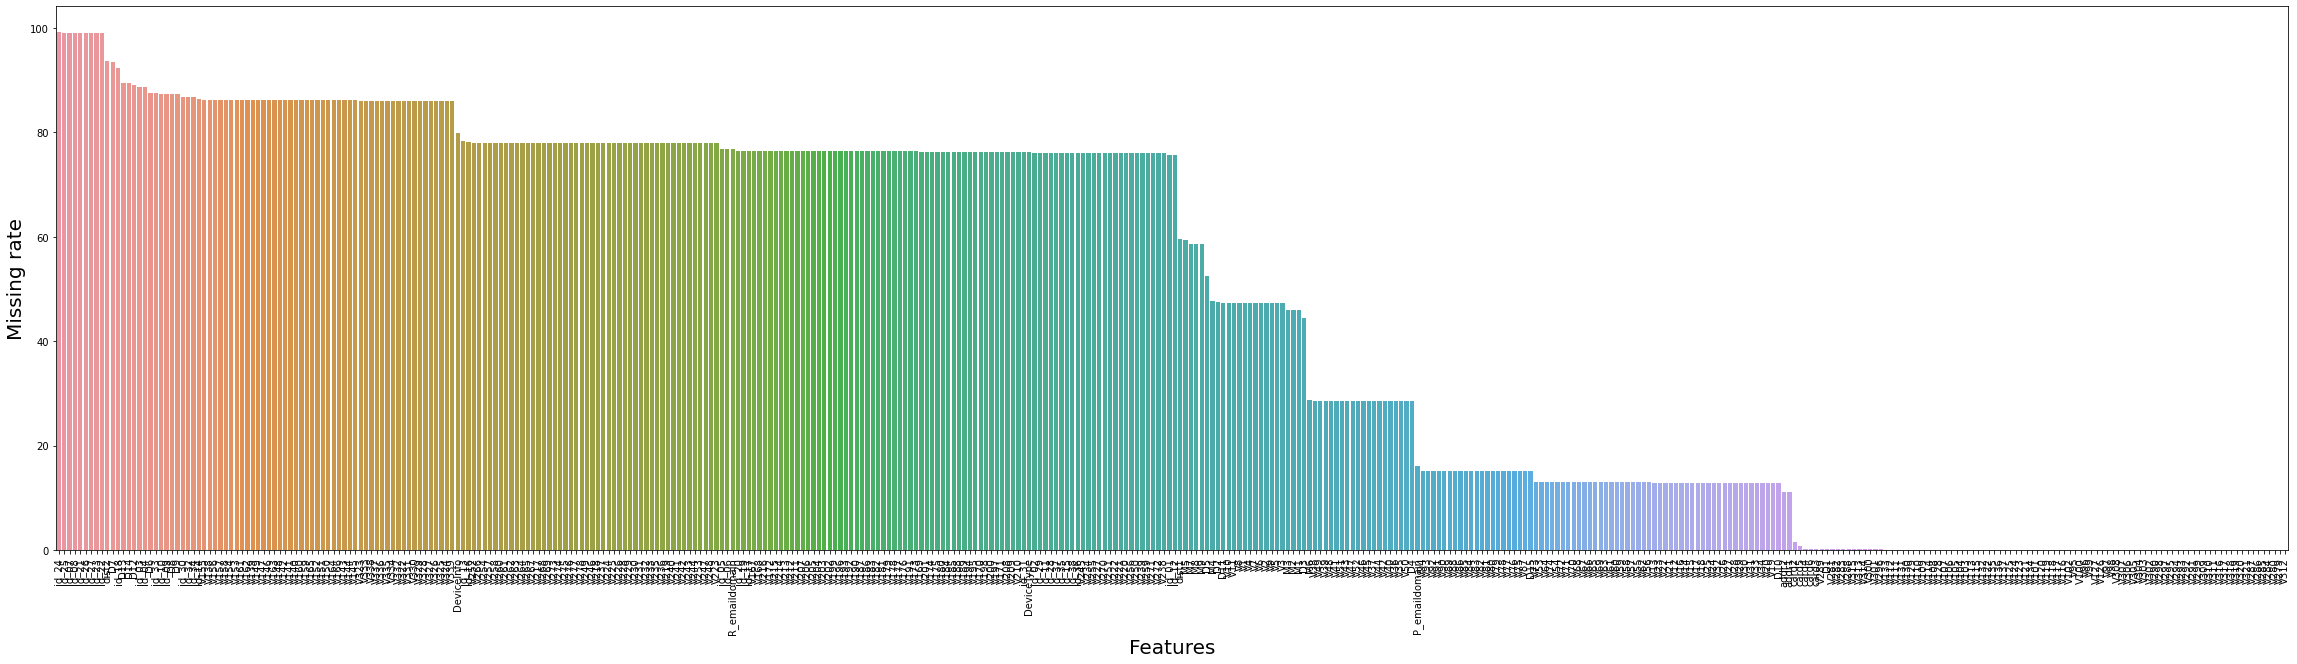

In [11]:
import seaborn as sns
null_variables = train_df.isnull().sum()/len(train_df) * 100
null_variables = null_variables.drop(null_variables[null_variables == 0].index).sort_values(ascending=False)[:500]
plt.subplots(figsize=(40,10))
plt.xticks(rotation='90')
sns.barplot(null_variables.index, null_variables)
plt.xlabel('Features', fontsize=20)
plt.ylabel('Missing rate', fontsize=20)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  


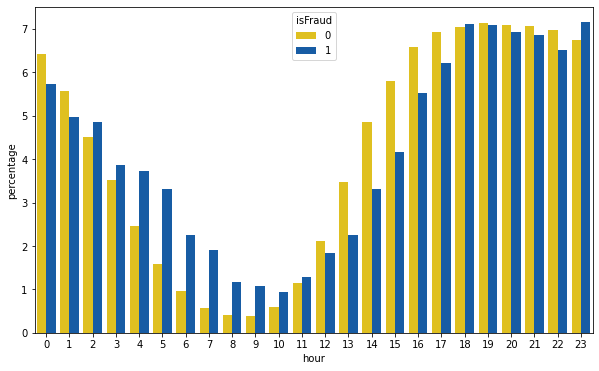

In [12]:
train_df['hour'] = (train_df['TransactionDT']//(3600))%24
test_df['hour'] = (test_df['TransactionDT']//(3600))%24

train_hour = (train_df.groupby(['isFraud'])['hour']
                     .value_counts(normalize=True)
                     .rename('percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('hour'))

plt.subplots(figsize=(10,6))
sns.barplot(x="hour", y="percentage", hue="isFraud", data=train_hour, palette=["#FFD500", "#005BBB"]);

In [13]:
cols1=("R_emaildomain","D6","D7","D8","D9","D12","D13","D14","M7","M8","M9","V138","V139","V140","V141","V142","V143","V144","V145","V146","V147","V148","V149","V150","V151","V152","V153","V154","V155","V156","V157","V158","V159","V160","V161","V162","V163","V164","V165","V166","V167","V168","V169","V170","V171","V172","V173","V174","V175","V176","V177","V178","V179","V180","V181","V182","V183","V184","V185","V186","V187","V188","V189","V190","V191","V192","V193","V194","V195","V196","V197","V198","V199","V200","V201","V202","V203","V204","V205","V206","V207","V208","V209","V210","V211","V212","V213","V214","V215","V216","V217","V218","V219","V220","V221","V222","V223","V224","V225","V226","V227","V228","V229","V230","V231","V232","V233","V234","V235","V236","V237","V238","V239","V240","V241","V242","V243","V244","V245","V246","V247","V248","V249","V250","V250","V251","V252","V253","V254","V255","V256","V257","V258","V259","V260",
"V261","V262","V263","V264","V265","V266","V267","V268","V269","V270","V271","V272","V273","V274","V275","V276","V277","V278","V279","V280","V281","V282",
"V283","V284","V285","V286","V287","V288","V289","V290","V291","V292","V293","V294","V295","V296","V297","V298","V299","V300","V301","V302","V303","V304",
"V305","V306","V307","V308","V309","V310","V311","V312","V313","V314","V315","V316","V317","V318","V319","V320","V321","V322","V323","V324","V325","V326","V327",
"V328","V329","V330","V331","V332","V333","V334","V335","V336","V337","V338","V339")
df1 = df1.drop(*cols1)

In [14]:
print("Number of column in train_transaction after column deletion: ")
len(df1.columns)

Number of column in train_transaction after column deletion: 


181

In [5]:
combined_df = pd.concat([train_df.drop(columns=['isFraud', 'TransactionID']), test_df.drop(columns='TransactionID')])
print(combined_df.shape)

# Dependent variable
y = train_df['isFraud']
print(y.shape)

# Dropping columns with more than 20% missing values 
mv = combined_df.isnull().sum()/len(combined_df)
combined_mv_df = combined_df.drop(columns=mv[mv>0.2].index)
del combined_df, train_df, test_df
print(combined_mv_df.shape)

(1097231, 432)
(590540,)
(1097231, 180)


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0, 0.5, 'Missing rate')

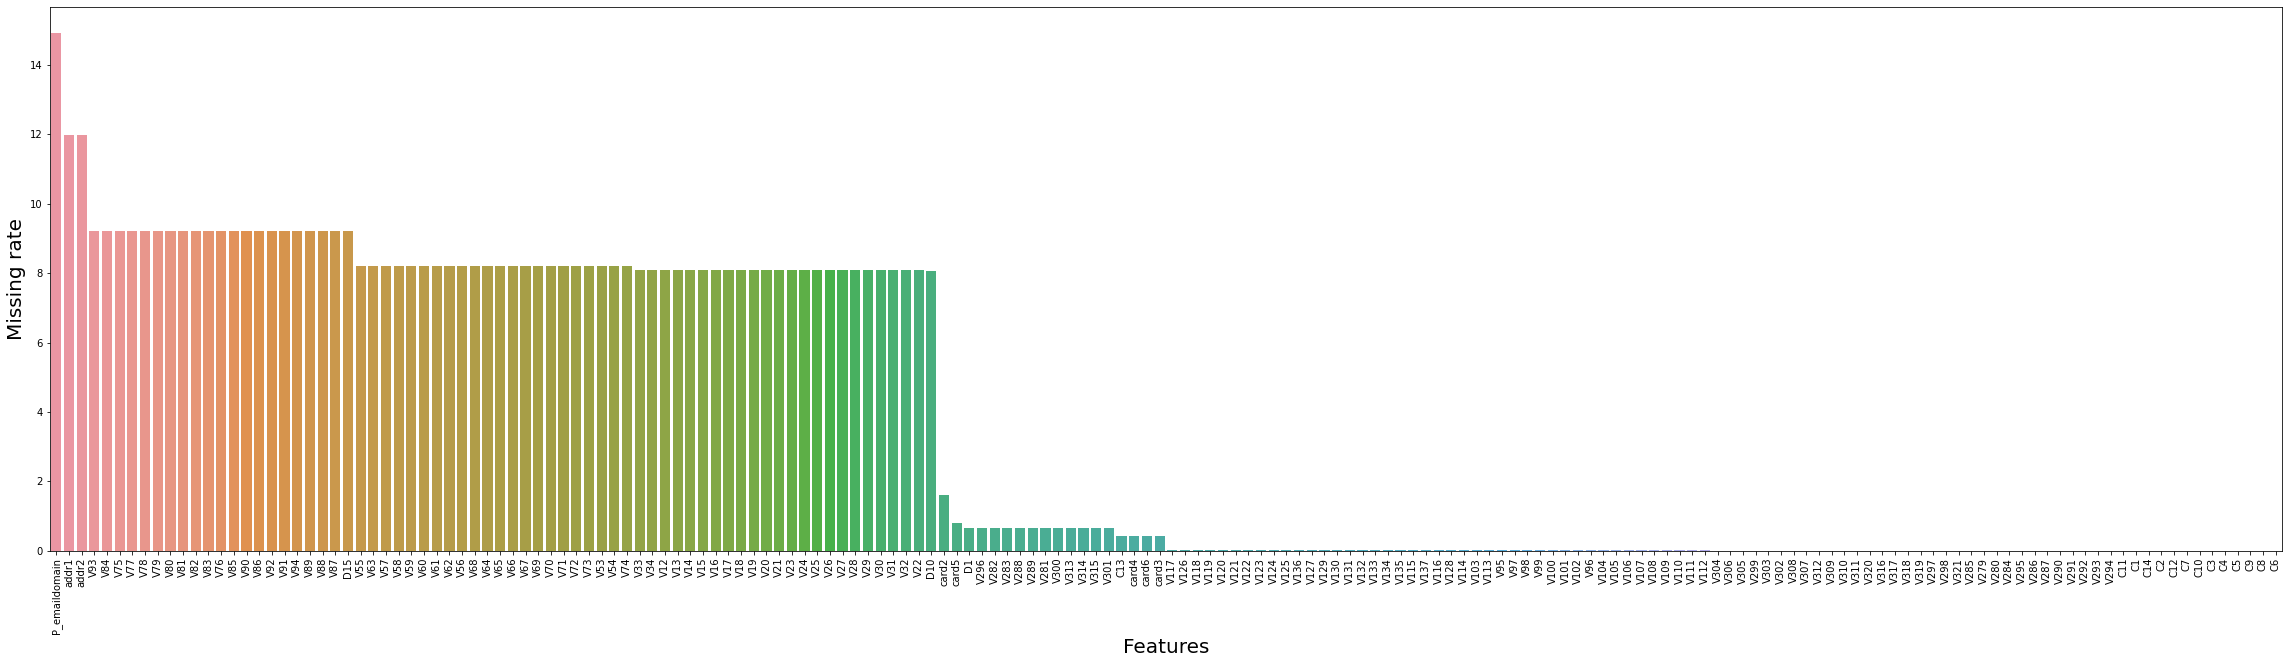

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns
null_variables = combined_mv_df.isnull().sum()/len(combined_mv_df) * 100
null_variables = null_variables.drop(null_variables[null_variables == 0].index).sort_values(ascending=False)[:500]
plt.subplots(figsize=(40,10))
plt.xticks(rotation='90')
sns.barplot(null_variables.index, null_variables)
plt.xlabel('Features', fontsize=20)
plt.ylabel('Missing rate', fontsize=20)

In [17]:
print("Number of column in train_identity before column deletion: ")
len(df.columns)

Number of column in train_identity before column deletion: 


41

In [18]:
cols=('id_07', 'id_08', 'id_21','id_22','id_23','id_24','id_25','id_26','id_27')
df = df.drop(*cols)

In [19]:
print("Number of column in train_identity after column deletion: ")
len(df.columns)

Number of column in train_identity after column deletion: 


32

In [6]:
del df1, df

In [6]:
# Filtering numerical data
num_mv_df = combined_mv_df.select_dtypes(include=np.number)
print(num_mv_df.shape)

# Filtering categorical data
cat_mv_df = combined_mv_df.select_dtypes(exclude=np.number)
print(cat_mv_df.shape)
del combined_mv_df

# Filling missing values by median for numerical columns 
imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
num_df = pd.DataFrame(imp_median.fit_transform(num_mv_df), columns=num_mv_df.columns)
del num_mv_df
print(num_df.shape)

# Filling missing values by most frequent value for categorical columns
imp_max = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cat_df = pd.DataFrame(imp_max.fit_transform(cat_mv_df), columns=cat_mv_df.columns)
del cat_mv_df
print(cat_df.shape)

# Concatinating numerical and categorical data
combined_df_cleaned = pd.concat([num_df, cat_df], axis=1)
del num_df, cat_df

# Verifying missing values
print(f'Total missing values: {combined_df_cleaned.isnull().sum().sum()}')
print(combined_df_cleaned.shape)
combined_df_cleaned.head()

(1097231, 176)
(1097231, 4)
(1097231, 176)
(1097231, 4)
Total missing values: 0
(1097231, 180)


,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,C1,C2,...,V316,V317,V318,V319,V320,V321,ProductCD,card4,card6,P_emaildomain
0,86400.0,68.5,13926.0,361.0,150.0,142.0,315.0,87.0,1.0,1.0,...,0.0,117.0,0.0,0.0,0.0,0.0,W,discover,credit,gmail.com
1,86401.0,29.0,2755.0,404.0,150.0,102.0,325.0,87.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,W,mastercard,credit,gmail.com
2,86469.0,59.0,4663.0,490.0,150.0,166.0,330.0,87.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,W,visa,debit,outlook.com
3,86499.0,50.0,18132.0,567.0,150.0,117.0,476.0,87.0,2.0,5.0,...,50.0,1404.0,790.0,0.0,0.0,0.0,W,mastercard,debit,yahoo.com
4,86506.0,50.0,4497.0,514.0,150.0,102.0,420.0,87.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,H,mastercard,credit,gmail.com


In [7]:
combined_df_encoded = pd.get_dummies(combined_df_cleaned, drop_first=True)
print(combined_df_encoded.shape)
del combined_df_cleaned
combined_df_encoded.head()
X = combined_df_encoded

(1097231, 245)


In [8]:
X = combined_df_encoded.iloc[:len_train_df]
print(X.shape)
test = combined_df_encoded.iloc[len_train_df:]
print(test.shape)
del combined_df_encoded
X

(590540, 245)
(506691, 245)


,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,C1,C2,...,P_emaildomain_web.de,P_emaildomain_windstream.net,P_emaildomain_yahoo.co.jp,P_emaildomain_yahoo.co.uk,P_emaildomain_yahoo.com,P_emaildomain_yahoo.com.mx,P_emaildomain_yahoo.de,P_emaildomain_yahoo.es,P_emaildomain_yahoo.fr,P_emaildomain_ymail.com
0,86400.0,68.500000,13926.0,361.0,150.0,142.0,315.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,86401.0,29.000000,2755.0,404.0,150.0,102.0,325.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2,86469.0,59.000000,4663.0,490.0,150.0,166.0,330.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,86499.0,50.000000,18132.0,567.0,150.0,117.0,476.0,87.0,2.0,5.0,...,0,0,0,0,1,0,0,0,0,0
4,86506.0,50.000000,4497.0,514.0,150.0,102.0,420.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,15811047.0,49.000000,6550.0,361.0,150.0,226.0,272.0,87.0,2.0,1.0,...,0,0,0,0,0,0,0,0,0,0
590536,15811049.0,39.500000,10444.0,225.0,150.0,224.0,204.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
590537,15811079.0,30.953125,12037.0,595.0,150.0,224.0,231.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
590538,15811088.0,117.000000,7826.0,481.0,150.0,224.0,387.0,87.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import plot_precision_recall_curve, precision_recall_curve, plot_roc_curve, roc_curve, plot_confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, classification_report, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit

In [10]:
train = pd.concat([X, y], axis=1)
train.sort_values('TransactionDT', inplace=True)
X = train.drop(['isFraud'], axis=1)
y = train['isFraud']
X_train,X_val,y_train,y_val = train_test_split(X, y, test_size = 0.2,random_state =42)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
del y, train

(472432, 245) (118108, 245) (472432,) (118108,)


In [11]:
# Random Forest Classifier
rfc = RandomForestClassifier(criterion='entropy', max_features='sqrt', max_samples=0.5, min_samples_split=80)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_val)
print(classification_report(y_val, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    113858
           1       0.91      0.30      0.45      4250

    accuracy                           0.97    118108
   macro avg       0.94      0.65      0.72    118108
weighted avg       0.97      0.97      0.97    118108



In [12]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb= xgb.predict(X_val)
print(classification_report(y_val, y_pred_xgb, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113858
           1       0.92      0.48      0.64      4250

    accuracy                           0.98    118108
   macro avg       0.95      0.74      0.81    118108
weighted avg       0.98      0.98      0.98    118108



/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


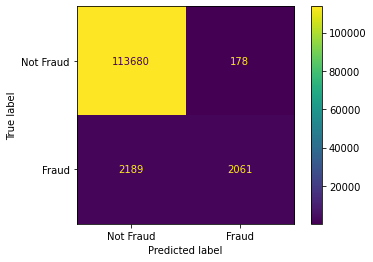

In [13]:
plot_confusion_matrix(xgb, X_val, y_val, values_format = '', 
                      display_labels=['Not Fraud', 'Fraud'])

In [14]:
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)
y_pred_lgb= lgb.predict(X_val)
print(classification_report(y_val, y_pred_lgb, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113858
           1       0.89      0.42      0.57      4250

    accuracy                           0.98    118108
   macro avg       0.94      0.71      0.78    118108
weighted avg       0.98      0.98      0.97    118108



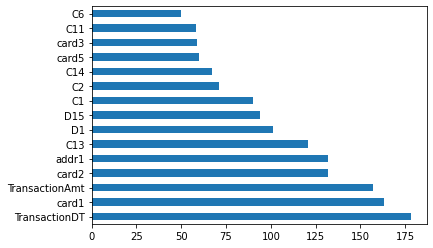

In [17]:
pd.Series(lgb.feature_importances_, index=X.columns).nlargest(15).plot(kind='barh')
plt.show()

/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


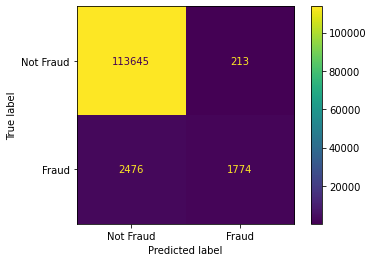

In [18]:
plot_confusion_matrix(lgb, X_val, y_val, values_format = '', 
                      display_labels=['Not Fraud', 'Fraud'])

In [ ]:
predictions = lgb.predict(test)
predictions

In [19]:

lgb_recall = recall_score(y_val, y_pred_lgb)
lgb_f1_score = f1_score(y_val, y_pred_lgb)
lgb_AUC = roc_auc_score(y_val, lgb.predict_proba(X_val)[:, 1])

xgb_recall = recall_score(y_val, y_pred_xgb)
xgb_f1_score = f1_score(y_val, y_pred_xgb)
xgb_AUC = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1],average='micro')

rfc_recall = recall_score(y_val, y_pred)
rfc_f1_score = f1_score(y_val, y_pred)
rfc_AUC = roc_auc_score(y_val, rfc.predict_proba(X_val)[:, 1])

df_eval=pd.DataFrame({ 'Model':["LightGBM",'XGBOOST','RandomForest'],
                        'Recall':[lgb_recall,xgb_recall,rfc_recall],
                        'F1':[lgb_f1_score,xgb_f1_score,rfc_f1_score],
                        'AUC':[lgb_AUC,xgb_AUC,rfc_AUC]})
df_eval

,Model,Recall,F1,AUC
0,LightGBM,0.417412,0.568863,0.928212
1,XGBOOST,0.484941,0.635229,0.938370
2,RandomForest,0.297647,0.448820,0.923869
